### Film Permits in New York City 2023 - 2026

In [17]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 4)

# folium is the only extra library needed
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'folium', '-q'])
import folium
from folium.plugins import MarkerCluster

#### 1. Load Dataset

In [18]:
df_permits = pd.read_csv("./Film_Permits_2026.csv")


#### 2. Understanding the Dataset

In [19]:
df_permits

,EventID,EventType,StartDateTime,EndDateTime,EnteredOn,EventAgency,ParkingHeld,Borough,CommunityBoard(s),PolicePrecinct(s),Category,SubCategoryName,Country,ZipCode(s)
0,915113,Shooting Permit,01/28/2026 02:00:00 AM,01/28/2026 11:59:00 PM,01/26/2026 03:13:39 PM,Mayor's Office of Media & Entertainment,JEWEL STREET between MESEROLE AVENUE and CALYE...,Brooklyn,"1,","94,",Television,Cable-episodic,United States of America,"11211, 11222, 11249,"
1,915034,Theater Load in and Load Outs,01/27/2026 12:01:00 PM,01/28/2026 06:00:00 AM,01/26/2026 11:36:31 AM,Mayor's Office of Media & Entertainment,WEST 51 STREET between 5 AVENUE and 6 AVENUE...,Manhattan,"5,","18,",Theater,Theater,United States of America,"10019, 10020, 10112,"
2,914851,Shooting Permit,01/27/2026 06:00:00 AM,01/27/2026 10:00:00 PM,01/23/2026 03:44:43 PM,Mayor's Office of Media & Entertainment,EAST 92 STREET between LEXINGTON AVENUE and ...,Manhattan,"8,","19,",Film,Feature,United States of America,"10128,"
3,914823,Shooting Permit,01/27/2026 07:00:00 AM,01/27/2026 11:00:00 PM,01/23/2026 02:15:14 PM,Mayor's Office of Media & Entertainment,WEST 46 STREET between 6 AVENUE and 7 AVENUE,Manhattan,"5,","18,",Commercial,Commercial,United States of America,"10036,"
4,914748,Shooting Permit,01/27/2026 08:00:00 AM,01/27/2026 09:00:00 PM,01/23/2026 10:20:01 AM,Mayor's Office of Media & Entertainment,NORTH HENRY STREET between GREENPOINT AVENUE a...,Brooklyn,"1,","94,",Television,Episodic series,United States of America,"11222,"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16963,737215,Shooting Permit,09/11/2023 07:00:00 PM,09/12/2023 04:00:00 AM,NaN,Mayor's Office of Media & Entertainment,WEST 46 STREET between 10 AVENUE and 11 AVENUE,Manhattan,"4,","18,",Film,Short,United States of America,"10036,"
16964,802566,Theater Load in and Load Outs,08/01/2024 12:01:00 PM,08/02/2024 06:00:00 AM,NaN,Mayor's Office of Media & Entertainment,WEST 65 STREET between COLUMBUS AVENUE and A...,Manhattan,"7,","20,",Theater,Theater,United States of America,"10023,"
16965,817273,Shooting Permit,10/29/2024 06:00:00 AM,10/29/2024 06:00:00 PM,NaN,Mayor's Office of Media & Entertainment,WEST 43 STREET between 5 AVENUE and 6 AVENUE,Manhattan,"5,","14, 18,",Commercial,Commercial,United States of America,"10017, 10020, 10036, 10173,"
16966,842912,Theater Load in and Load Outs,03/29/2025 12:01:00 PM,03/29/2025 11:59:00 PM,NaN,Mayor's Office of Media & Entertainment,EAST 11 STREET between 3 AVENUE and 4 AVENUE...,Manhattan,"3,","9,",Theater,Theater,United States of America,"10003,"


In [20]:
df_permits.dtypes

EventID              int64
EventType              str
StartDateTime          str
EndDateTime            str
EnteredOn              str
EventAgency            str
ParkingHeld            str
Borough                str
CommunityBoard(s)      str
PolicePrecinct(s)      str
Category               str
SubCategoryName        str
Country                str
ZipCode(s)             str
dtype: object

In [21]:
print("Rows:", len(df_permits))
print("Columns:", len(df_permits.columns))

Rows: 16968
Columns: 14


#### 3. Cleaning the dataset

##### 3.1 Extracting dates abd calculate shooting duration

In [22]:
df_permits['StartDateTime'] = pd.to_datetime(df_permits['StartDateTime'], errors='coerce')
df_permits['EndDateTime']   = pd.to_datetime(df_permits['EndDateTime'],   errors='coerce')

# Split into useful parts
df_permits['StartDate'] = df_permits['StartDateTime'].dt.date
df_permits['StartHour'] = df_permits['StartDateTime'].dt.hour
df_permits['Year']      = df_permits['StartDateTime'].dt.year
df_permits['Month']     = df_permits['StartDateTime'].dt.month
df_permits['DayOfWeek'] = df_permits['StartDateTime'].dt.day_name()

# How long each shoot lasts (in hours)
df_permits['DurationHours'] = (
    (df_permits['EndDateTime'] - df_permits['StartDateTime'])
    .dt.total_seconds() / 3600
)

print('Date columns created. Sample durations:')
df_permits[['StartDateTime','EndDateTime','DurationHours']].head(5)

C:\Users\marya\AppData\Local\Temp\ipykernel_38604\1193326289.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_permits['EndDateTime']   = pd.to_datetime(df_permits['EndDateTime'],   errors='coerce')


Date columns created. Sample durations:


,StartDateTime,EndDateTime,DurationHours
0,2026-01-28 02:00:00,2026-01-28 23:59:00,21.983333
1,2026-01-27 12:01:00,2026-01-28 06:00:00,17.983333
2,2026-01-27 06:00:00,2026-01-27 22:00:00,16.000000
3,2026-01-27 07:00:00,2026-01-27 23:00:00,16.000000
4,2026-01-27 08:00:00,2026-01-27 21:00:00,13.000000


##### 3.2 Cleaning the zip code row - Keep only the first valid 5 digit zipcode

In [23]:
# Raw ZipCode(s) looks like: '11211, 11222, 11249,'
# Split on comma, strip spaces, keep the first valid 5-digit code

def first_valid_zip(raw):
    if pd.isna(raw):
        return np.nan
    for part in str(raw).split(','):
        part = part.strip()
        if part.isdigit() and len(part) == 5:
            return int(part)
    return np.nan

df_permits['ZipCode'] = df_permits['ZipCode(s)'].apply(first_valid_zip)

print(f"Rows with a valid ZIP : {df_permits['ZipCode'].notna().sum():,}")
print(f"Rows missing ZIP      : {df_permits['ZipCode'].isna().sum():,}")

# Preview before / after
df_permits[['ZipCode(s)','ZipCode']].head(6)

Rows with a valid ZIP : 16,958
Rows missing ZIP      : 10


,ZipCode(s),ZipCode
0,"11211, 11222, 11249,",11211.0
1,"10019, 10020, 10112,",10019.0
2,"10128,",10128.0
3,"10036,",10036.0
4,"11222,",11222.0
5,"11101,",11101.0


#### 4. Load coordinates dataset

In [24]:
df_coordinates = pd.read_csv("./centroid-coordinates.csv")

In [25]:
df_coordinates

,zcta5,intptlat,intptlong
0,601,18.180555,-66.749961
1,602,18.361945,-67.175597
2,603,18.457399,-67.124867
3,606,18.158327,-66.932928
4,610,18.295304,-67.125180
...,...,...,...
33786,99923,56.000439,-130.037307
33787,99925,55.550203,-132.945947
33788,99926,55.138468,-131.470377
33789,99927,56.331881,-133.606420


#### 5. Merge datasets to get coordinates for each zip code

In [26]:
df_coordinates = df_coordinates.rename(columns={
    'zcta5'    : 'ZipCode',
    'intptlat' : 'lat',
    'intptlong': 'lng'})

# Left-join: every permit row keeps its coordinates if the ZIP matched
permits = df_permits.merge(
    df_coordinates[['ZipCode','lat','lng']],
    on='ZipCode',
    how='left'
)

In [27]:
df_permits

,EventID,EventType,StartDateTime,EndDateTime,EnteredOn,EventAgency,ParkingHeld,Borough,CommunityBoard(s),PolicePrecinct(s),...,SubCategoryName,Country,ZipCode(s),StartDate,StartHour,Year,Month,DayOfWeek,DurationHours,ZipCode
0,915113,Shooting Permit,2026-01-28 02:00:00,2026-01-28 23:59:00,01/26/2026 03:13:39 PM,Mayor's Office of Media & Entertainment,JEWEL STREET between MESEROLE AVENUE and CALYE...,Brooklyn,"1,","94,",...,Cable-episodic,United States of America,"11211, 11222, 11249,",2026-01-28,2.0,2026.0,1.0,Wednesday,21.983333,11211.0
1,915034,Theater Load in and Load Outs,2026-01-27 12:01:00,2026-01-28 06:00:00,01/26/2026 11:36:31 AM,Mayor's Office of Media & Entertainment,WEST 51 STREET between 5 AVENUE and 6 AVENUE...,Manhattan,"5,","18,",...,Theater,United States of America,"10019, 10020, 10112,",2026-01-27,12.0,2026.0,1.0,Tuesday,17.983333,10019.0
2,914851,Shooting Permit,2026-01-27 06:00:00,2026-01-27 22:00:00,01/23/2026 03:44:43 PM,Mayor's Office of Media & Entertainment,EAST 92 STREET between LEXINGTON AVENUE and ...,Manhattan,"8,","19,",...,Feature,United States of America,"10128,",2026-01-27,6.0,2026.0,1.0,Tuesday,16.000000,10128.0
3,914823,Shooting Permit,2026-01-27 07:00:00,2026-01-27 23:00:00,01/23/2026 02:15:14 PM,Mayor's Office of Media & Entertainment,WEST 46 STREET between 6 AVENUE and 7 AVENUE,Manhattan,"5,","18,",...,Commercial,United States of America,"10036,",2026-01-27,7.0,2026.0,1.0,Tuesday,16.000000,10036.0
4,914748,Shooting Permit,2026-01-27 08:00:00,2026-01-27 21:00:00,01/23/2026 10:20:01 AM,Mayor's Office of Media & Entertainment,NORTH HENRY STREET between GREENPOINT AVENUE a...,Brooklyn,"1,","94,",...,Episodic series,United States of America,"11222,",2026-01-27,8.0,2026.0,1.0,Tuesday,13.000000,11222.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16963,737215,Shooting Permit,2023-09-11 19:00:00,2023-09-12 04:00:00,NaN,Mayor's Office of Media & Entertainment,WEST 46 STREET between 10 AVENUE and 11 AVENUE,Manhattan,"4,","18,",...,Short,United States of America,"10036,",2023-09-11,19.0,2023.0,9.0,Monday,9.000000,10036.0
16964,802566,Theater Load in and Load Outs,2024-08-01 12:01:00,2024-08-02 06:00:00,NaN,Mayor's Office of Media & Entertainment,WEST 65 STREET between COLUMBUS AVENUE and A...,Manhattan,"7,","20,",...,Theater,United States of America,"10023,",2024-08-01,12.0,2024.0,8.0,Thursday,17.983333,10023.0
16965,817273,Shooting Permit,2024-10-29 06:00:00,2024-10-29 18:00:00,NaN,Mayor's Office of Media & Entertainment,WEST 43 STREET between 5 AVENUE and 6 AVENUE,Manhattan,"5,","14, 18,",...,Commercial,United States of America,"10017, 10020, 10036, 10173,",2024-10-29,6.0,2024.0,10.0,Tuesday,12.000000,10017.0
16966,842912,Theater Load in and Load Outs,2025-03-29 12:01:00,2025-03-29 23:59:00,NaN,Mayor's Office of Media & Entertainment,EAST 11 STREET between 3 AVENUE and 4 AVENUE...,Manhattan,"3,","9,",...,Theater,United States of America,"10003,",2025-03-29,12.0,2025.0,3.0,Saturday,11.966667,10003.0


#### 6. Data Visualization

##### 6.1 Which categories were given permits by the Mayor's Office of Media and Entertainment?

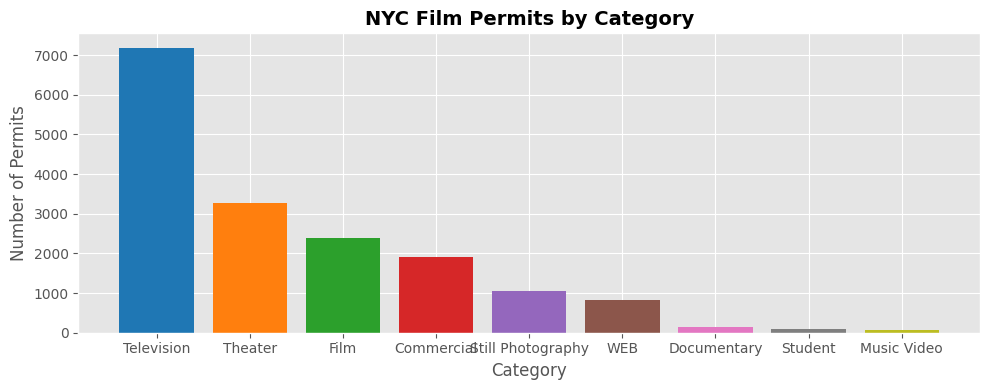

In [36]:
cat_counts = permits['Category'].value_counts()

fig, ax = plt.subplots()
bars = ax.bar(cat_counts.index, cat_counts.values,
              color=plt.cm.tab10.colors[:len(cat_counts)])

ax.set_title('NYC Film Permits by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Permits')
plt.tight_layout()
plt.show()

##### 6.2 Which subcategories did these belong to?

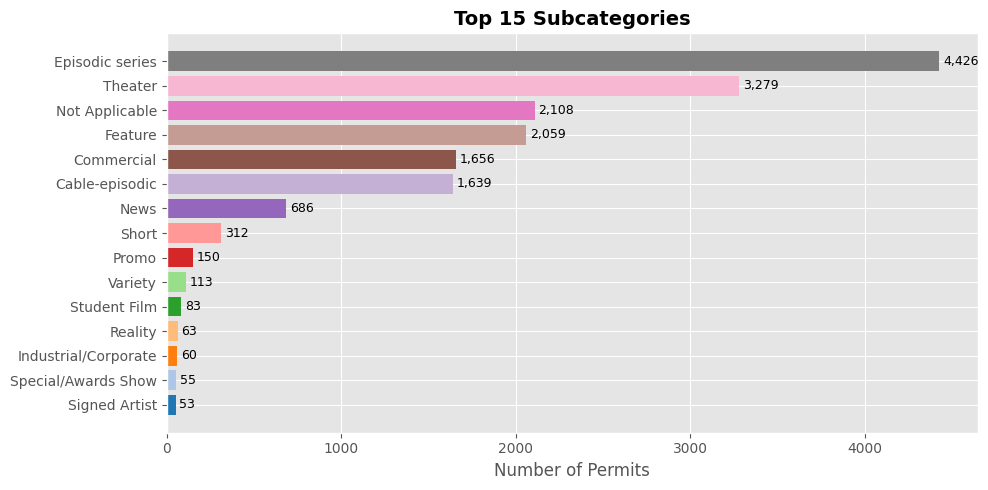

In [ ]:
sub_counts = permits['SubCategoryName'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sub_counts.index[::-1], sub_counts.values[::-1],
               color=plt.cm.tab20.colors[:15])

ax.set_title('Top 15 Subcategories', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Permits')
plt.tight_layout()

plt.show()

##### 6.3 Permits by Borough

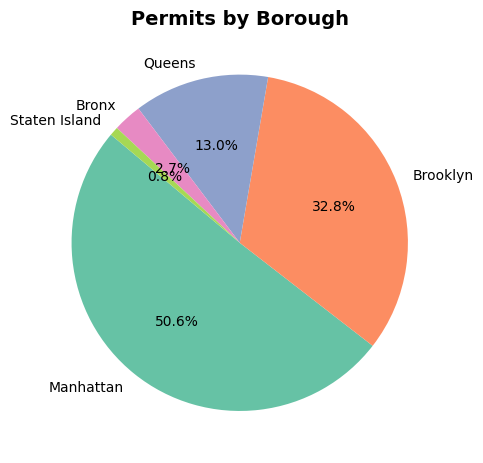

In [ ]:
borough_counts = permits['Borough'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    borough_counts.values,
    labels=borough_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set2.colors[:len(borough_counts)]
)
ax.set_title('Permits by Borough', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 6.4 Permits issued by year

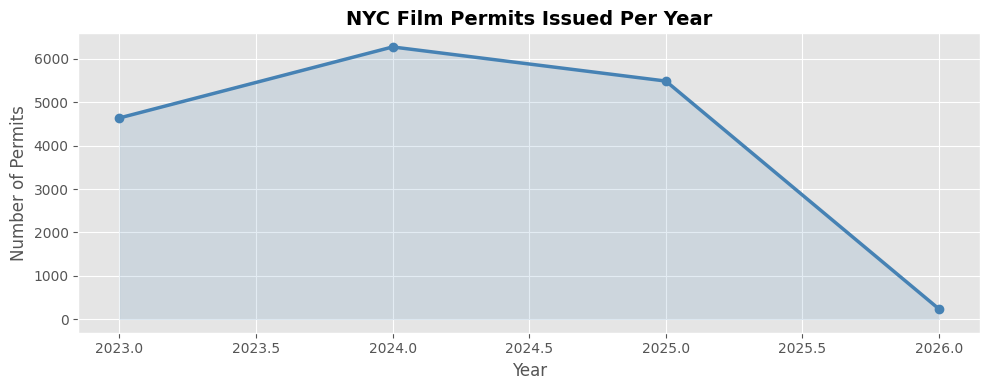

In [39]:
year_counts = (
    permits[permits['Year'] >= 2022]['Year']
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots()
ax.plot(year_counts.index, year_counts.values,
        marker='o', linewidth=2.5, color='steelblue')
ax.fill_between(year_counts.index, year_counts.values,
                alpha=0.15, color='steelblue')

ax.set_title('NYC Film Permits Issued Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Permits')
plt.tight_layout()
plt.show()

##### 6.5 Shooting duration by category

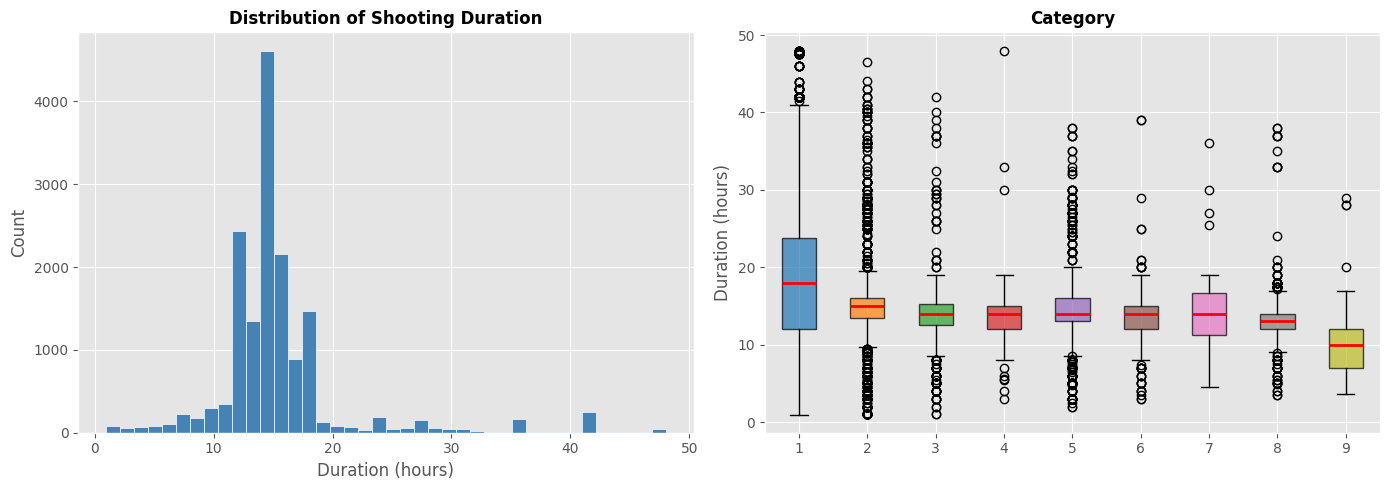


Duration summary (hours):
count    15830.00
mean        15.54
std          6.08
min          0.98
25%         13.00
50%         14.50
75%         16.00
max         48.00
Name: DurationHours, dtype: float64


In [41]:
dur = permits[(permits['DurationHours'] >= 0.5) &
              (permits['DurationHours'] <= 48)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Histogram --
axes[0].hist(dur['DurationHours'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Shooting Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Count')

# -- Boxplot by category --
cat_order = (dur.groupby('Category')['DurationHours']
               .median()
               .sort_values(ascending=False).index)
groups = [dur[dur['Category'] == c]['DurationHours'].values for c in cat_order]
bp = axes[1].boxplot(groups, vert=True, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
colors = plt.cm.tab10.colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (hours)')

plt.tight_layout()
plt.show()

print('\nDuration summary (hours):')
print(dur['DurationHours'].describe().round(2))

##### 6.6 Top 20 zip codes

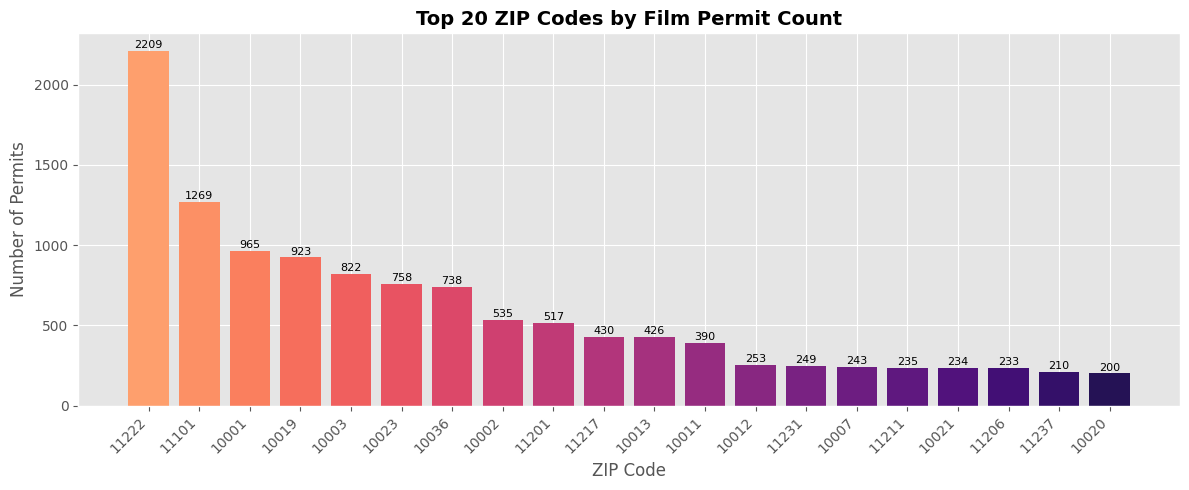

In [33]:
top_zips = (
    permits['ZipCode']
    .dropna()
    .astype(int)
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_zips.index.astype(str), top_zips.values,
              color=plt.cm.magma_r(np.linspace(0.2, 0.85, 20)))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=8)

ax.set_title('Top 20 ZIP Codes by Film Permit Count', fontsize=14, fontweight='bold')
ax.set_xlabel('ZIP Code')
ax.set_ylabel('Number of Permits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_top_zips.png', dpi=150)
plt.show()

#### 7. Mapping Zipcodes on the map

In [35]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'folium', '-q'])
import folium
from folium.plugins import FastMarkerCluster

CATEGORY_COLORS = {
    'Television'       : 'blue',
    'Theater'          : 'purple',
    'Film'             : 'red',
    'Commercial'       : 'orange',
    'Still Photography': 'green',
    'WEB'              : 'cadetblue',
    'Documentary'      : 'darkred',
    'Student'          : 'gray',
    'Music Video'      : 'pink',
}

map_df = permits.dropna(subset=['lat', 'lng']).copy()
map_df['color'] = map_df['Category'].map(CATEGORY_COLORS).fillna('lightgray')

fig = folium.Figure(width=900, height=500)
m = folium.Map(location=(40.7128, -74.0060), zoom_start=11, tiles='OpenStreetMap')

# Sample to 3000 rows so it doesn't hang
sample_df = map_df.sample(min(3000, len(map_df)), random_state=42)

for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=(row['lat'], row['lng']),
        radius=5,
        color=row['color'],
        fill=True,
        fill_color=row['color'],
        fill_opacity=0.6,
        tooltip=f"{row['Category']} | ZIP {int(row['ZipCode']) if not pd.isna(row['ZipCode']) else 'N/A'}"
    ).add_to(m)

fig.add_child(m)
fig